# Statistics §1–§6: Textbook Formalism
## From Kolmogorov Axioms to the Central Limit Theorem

> **Physics creates new math.**
> Boltzmann needed entropy → invented statistical mechanics.
> Einstein explained Brownian motion → built the diffusion equation.
> Bohr/Heisenberg needed |ψ|² → Born invented quantum probability.
> Jalali's TS-DFT reads shot noise → Poisson statistics define the SNR floor.

This notebook uses `sympy.init_printing()` to render every equation in
LaTeX-quality typesetting, exactly as it appears in a probability textbook.


In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math
sp.init_printing(use_latex='mathjax')

# Global symbols reused across sections
x, y, t, n, k, p, q, lam = sp.symbols('x y t n k p q lambda', positive=True)
mu, sigma, z = sp.symbols('mu sigma z', real=True)
s = sp.Symbol('s')   # moment-generating function variable


---
## §1 — Kolmogorov Axioms and Sample Spaces

A **probability space** is a triple $(\Omega, \mathcal{F}, P)$:

| Symbol | Name | Meaning |
|--------|------|---------|
| $\Omega$ | Sample space | all possible outcomes |
| $\mathcal{F}$ | $\sigma$-algebra | measurable events |
| $P$ | Probability measure | $P: \mathcal{F} \to [0,1]$ |

**Kolmogorov's three axioms** — everything in probability follows from these:


In [2]:
Omega, A, B, A_i = sp.symbols('Omega A B A_i')
P = sp.Function('P')
i = sp.Symbol('i', integer=True, positive=True)

# Axiom 1: Non-negativity
ax1 = sp.Ge(P(A), 0)

# Axiom 2: Normalization
ax2 = sp.Eq(P(Omega), 1)

# Axiom 3: Countable additivity (for disjoint A_i)
ax3 = sp.Eq(P(sp.Sum(A_i, (i, 1, sp.oo))),
            sp.Sum(P(A_i), (i, 1, sp.oo)))

print("Axiom 1 — Non-negativity:")
display(ax1)
print("\nAxiom 2 — Normalization:")
display(ax2)
print("\nAxiom 3 — Countable additivity (disjoint events):")
display(ax3)


Axiom 1 — Non-negativity:


P(A) ≥ 0


Axiom 2 — Normalization:


P(Ω) = 1


Axiom 3 — Countable additivity (disjoint events):


 ⎛  ∞     ⎞     ∞        
 ⎜ ___    ⎟    ___       
 ⎜ ╲      ⎟    ╲         
 ⎜  ╲     ⎟     ╲        
P⎜  ╱   Aᵢ⎟ =   ╱   P(Aᵢ)
 ⎜ ╱      ⎟    ╱         
 ⎜ ‾‾‾    ⎟    ‾‾‾       
 ⎝i = 1   ⎠   i = 1      

In [3]:
# Derived: Complement rule P(A^c) = 1 - P(A)
Ac = sp.Symbol('A^c')
complement = sp.Eq(P(Ac), 1 - P(A))

# Addition rule for any two events
P_A, P_B, P_AB = sp.symbols('P_A P_B P_{AB}', positive=True)
addition_rule = sp.Eq(sp.Symbol('P(A cup B)'), P_A + P_B - P_AB)

print("Complement rule:")
display(complement)
print("\nAddition rule:")
display(addition_rule)


Complement rule:


P(A__c) = 1 - P(A)


Addition rule:


P(A cup B) = P_A + P_B - P_{AB}

### Conditional Probability and Independence

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

Events $A, B$ are **independent** iff $P(A \cap B) = P(A)\,P(B)$.

**Bayes' Theorem** — the engine of inference:
$$P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)}$$


In [4]:
P_A_given_B = sp.Symbol('P(A|B)')
P_B_given_A = sp.Symbol('P(B|A)')

bayes = sp.Eq(P_A_given_B,
              P_B_given_A * P_A / P_B)

print("Bayes' Theorem:")
display(bayes)

# Numerical example: medical test
# P(disease) = 0.01, sensitivity = 0.99, specificity = 0.95
P_D  = 0.01     # prior
sens = 0.99     # P(+ | D)
spec = 0.95     # P(- | ~D)  => P(+ | ~D) = 0.05

P_pos = sens * P_D + (1 - spec) * (1 - P_D)   # total probability of +
P_D_given_pos = sens * P_D / P_pos

print(f"\nMedical test example:")
print(f"  P(disease) = {P_D},  sensitivity={sens},  specificity={spec}")
print(f"  P(test+)   = {P_pos:.4f}")
print(f"  P(D | +)   = {P_D_given_pos:.4f}  <- only {P_D_given_pos*100:.1f}% even with positive test!")


Bayes' Theorem:


         P(B|A)⋅P_A
P(A|B) = ──────────
            P_B    


Medical test example:
  P(disease) = 0.01,  sensitivity=0.99,  specificity=0.95
  P(test+)   = 0.0594
  P(D | +)   = 0.1667  <- only 16.7% even with positive test!


---
## §2 — Combinatorics: Counting the Sample Space

**Physics connection**: the number of microstates $\Omega$ in statistical
mechanics is a combinatorial count — Boltzmann's $S = k_B \ln \Omega$.


In [5]:
# Permutations and combinations
n_sym, r_sym = sp.symbols('n r', integer=True, positive=True)

P_nr = sp.factorial(n_sym) / sp.factorial(n_sym - r_sym)
C_nr = sp.factorial(n_sym) / (sp.factorial(r_sym) * sp.factorial(n_sym - r_sym))

perm_eq = sp.Eq(sp.Symbol('P(n,r)'), P_nr)
comb_eq = sp.Eq(sp.binomial(n_sym, r_sym), C_nr)

print("Permutations P(n,r) = n!/(n-r)!:")
display(perm_eq)
print("\nCombinations C(n,r) = n!/(r!(n-r)!):")
display(comb_eq)

# Pascal's identity
pascal = sp.Eq(sp.binomial(n_sym, r_sym),
               sp.binomial(n_sym-1, r_sym-1) + sp.binomial(n_sym-1, r_sym))
print("\nPascal's identity:")
display(pascal)
print("Verified:", sp.simplify(
    sp.binomial(n_sym, r_sym) -
    sp.binomial(n_sym-1,r_sym-1) - sp.binomial(n_sym-1,r_sym)) == 0)


Permutations P(n,r) = n!/(n-r)!:


            n!   
P(n,r) = ────────
         (n - r)!


Combinations C(n,r) = n!/(r!(n-r)!):


⎛n⎞       n!     
⎜ ⎟ = ───────────
⎝r⎠   r!⋅(n - r)!


Pascal's identity:


⎛n⎞   ⎛n - 1⎞   ⎛n - 1⎞
⎜ ⎟ = ⎜     ⎟ + ⎜     ⎟
⎝r⎠   ⎝  r  ⎠   ⎝r - 1⎠

Verified: True


In [6]:
# Binomial theorem  (1+x)^n = sum C(n,k) x^k
binom_theorem = sp.Eq((1 + x)**n_sym,
                      sp.Sum(sp.binomial(n_sym, k) * x**k, (k, 0, n_sym)))
print("Binomial Theorem:")
display(binom_theorem)

# Verify at n=4
lhs4 = sp.expand((1+x)**4)
rhs4 = sum(sp.binomial(4,j)*x**j for j in range(5))
print(f"  n=4 check: {sp.simplify(lhs4 - rhs4) == 0}")

# Stirling's approximation for large n (used in Boltzmann entropy)
n_val = sp.Symbol('n', positive=True)
stirling = sp.Eq(sp.log(sp.factorial(n_val)),
                 n_val*sp.log(n_val) - n_val +
                 sp.Rational(1,2)*sp.log(2*sp.pi*n_val))
print("\nStirling's approximation  ln(n!) approx:")
display(stirling)
print("  -> Boltzmann used this to derive S = k_B * ln(Omega)")


Binomial Theorem:


            n          
           ____        
           ╲           
            ╲          
       n     ╲    k ⎛n⎞
(x + 1)  =   ╱   x ⋅⎜ ⎟
            ╱       ⎝k⎠
           ╱           
           ‾‾‾‾        
           k = 0       

  n=4 check: True

Stirling's approximation  ln(n!) approx:


                         log(2⋅π⋅n)
log(n!) = n⋅log(n) - n + ──────────
                             2     

  -> Boltzmann used this to derive S = k_B * ln(Omega)


---
## §3 — Discrete Distributions

### 3.1 Binomial Distribution

$n$ independent Bernoulli trials, each success probability $p$:

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0,1,\ldots,n$$

**Mean** $\mu = np$, **Variance** $\sigma^2 = np(1-p)$.

**Physics link**: spin-$\frac{1}{2}$ particles — $n$ spins, each up with prob $p$.


In [7]:
# Binomial PMF symbolically
q_sym = 1 - p
binom_pmf = sp.Eq(sp.Symbol('P(X=k)'),
                  sp.binomial(n, k) * p**k * q_sym**(n-k))
print("Binomial PMF:")
display(binom_pmf)

binom_mean = sp.Eq(sp.Symbol('E[X]'), n * p)
binom_var  = sp.Eq(sp.Symbol('Var(X)'), n * p * q_sym)
print("Mean:"); display(binom_mean)
print("Variance:"); display(binom_var)

# MGF of Binomial: M(t) = (1-p+p*e^t)^n
t_mgf = sp.Symbol('t')
binom_mgf = sp.Eq(sp.Symbol('M_X(t)'),
                  (1 - p + p * sp.exp(t_mgf))**n)
print("\nMoment Generating Function:")
display(binom_mgf)


Binomial PMF:


          k        -k + n ⎛n⎞
P(X=k) = p ⋅(1 - p)      ⋅⎜ ⎟
                          ⎝k⎠

Mean:


E[X] = n⋅p

Variance:


Var(X) = n⋅p⋅(1 - p)


Moment Generating Function:


                       n
         ⎛   t        ⎞ 
M_X(t) = ⎝p⋅ℯ  - p + 1⎠ 

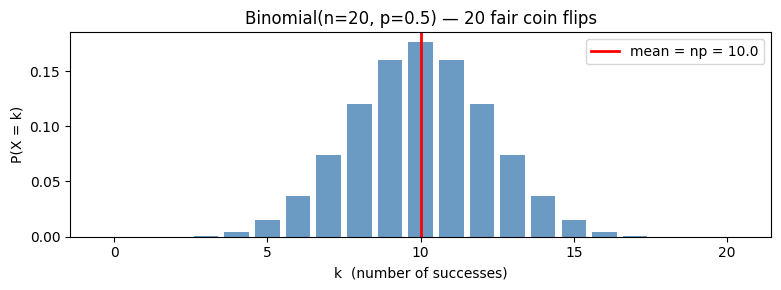

P(X=10) = 0.1762  (peak at mean)


In [8]:
# Numerical: P(X>=k) for coin flips
from math import comb as C
def binom_pmf_num(n_val, p_val, k_val):
    return C(n_val, k_val) * p_val**k_val * (1-p_val)**(n_val-k_val)

n_val, p_val = 20, 0.5
ks    = np.arange(0, n_val+1)
probs = np.array([binom_pmf_num(n_val, p_val, kk) for kk in ks])

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(ks, probs, color='steelblue', alpha=0.8)
ax.axvline(n_val*p_val, color='red', lw=2, label=f'mean = np = {n_val*p_val}')
ax.set_xlabel('k  (number of successes)')
ax.set_ylabel('P(X = k)')
ax.set_title(f'Binomial(n={n_val}, p={p_val}) — 20 fair coin flips')
ax.legend()
plt.tight_layout(); plt.savefig('binomial_pmf.png', dpi=100); plt.show()
print(f"P(X=10) = {binom_pmf_num(20,0.5,10):.4f}  (peak at mean)")


### 3.2 Poisson Distribution

The Poisson emerges as $n\to\infty$, $p\to 0$, $np = \lambda = \text{const}$:

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k = 0, 1, 2, \ldots$$

**Mean = Variance = $\lambda$** — this is *shot noise*: SNR $= \sqrt{\lambda}$.

**Physics creates new math here**: Poisson (1837) studied rare judicial errors.
Then Einstein (1905) showed photon arrivals are Poisson → defined shot noise.
Today: TS-DFT SNR floor is $\sqrt{N_{\text{photons}}}$.


In [9]:
# Poisson PMF
poisson_pmf = sp.Eq(sp.Symbol('P(X=k)'),
                    lam**k * sp.exp(-lam) / sp.factorial(k))
print("Poisson PMF:")
display(poisson_pmf)

# Mean and variance (both = lambda)
poisson_mean = sp.Eq(sp.Symbol('E[X]'), lam)
poisson_var  = sp.Eq(sp.Symbol('Var(X)'), lam)
poisson_snr  = sp.Eq(sp.Symbol('SNR'), sp.sqrt(lam))
print("Mean:"); display(poisson_mean)
print("Variance:"); display(poisson_var)
print("Shot-noise SNR:"); display(poisson_snr)

# Verify: sum P(k) = 1 via Taylor series of exp(lambda)
k_sym = sp.Symbol('k', integer=True, nonneg=True)
poisson_norm = sp.Sum(lam**k_sym * sp.exp(-lam) / sp.factorial(k_sym),
                      (k_sym, 0, sp.oo))
result = poisson_norm.doit()
print(f"\nSum of all probabilities = {sp.simplify(result)}")


Poisson PMF:


          k  -λ
         λ ⋅ℯ  
P(X=k) = ──────
           k!  

Mean:


E[X] = λ

Variance:


Var(X) = λ

Shot-noise SNR:


SNR = √λ


Sum of all probabilities = 1


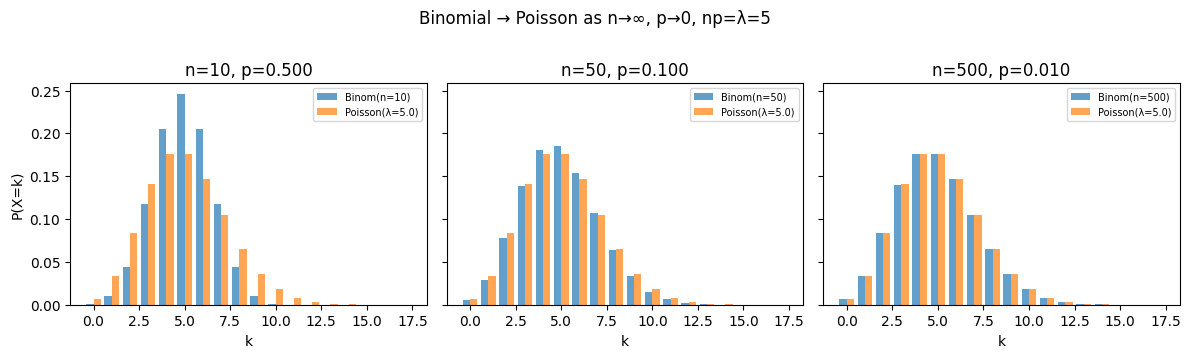

In [10]:
# Poisson vs Binomial convergence
import math

lam_val = 5.0
n_vals = [10, 50, 500]
ks_p = np.arange(0, 18)

def poisson_pmf_num(lam_v, k_v):
    return lam_v**k_v * np.exp(-lam_v) / math.factorial(k_v)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, n_v in zip(axes, n_vals):
    p_v = lam_val / n_v
    binom_p = [binom_pmf_num(n_v, p_v, kk) for kk in ks_p]
    pois_p  = [poisson_pmf_num(lam_val, kk) for kk in ks_p]
    ax.bar(ks_p - 0.2, binom_p, 0.4, label=f'Binom(n={n_v})', alpha=0.7)
    ax.bar(ks_p + 0.2, pois_p,  0.4, label=f'Poisson(λ={lam_val})', alpha=0.7)
    ax.set_title(f'n={n_v}, p={p_v:.3f}'); ax.legend(fontsize=7)
    ax.set_xlabel('k')
axes[0].set_ylabel('P(X=k)')
plt.suptitle('Binomial → Poisson as n→∞, p→0, np=λ=5', y=1.01)
plt.tight_layout(); plt.savefig('poisson_binom.png', dpi=100); plt.show()


---
## §4 — Continuous Distributions

### 4.1 The Gaussian (Normal) Distribution

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\,\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**Physics creates this distribution**: Maxwell (1860) derived the speed
distribution of gas molecules → first derivation of the Gaussian from
physics, not from Gauss's error theory.

The **error function** $\operatorname{erf}(z) = \frac{2}{\sqrt\pi}\int_0^z e^{-t^2}\,dt$
gives the CDF.


In [11]:
# Gaussian PDF and CDF symbolically
gauss_pdf = sp.Rational(1,1) / (sigma * sp.sqrt(2*sp.pi)) *             sp.exp(-(x - mu)**2 / (2*sigma**2))
gauss_eq  = sp.Eq(sp.Symbol('f(x)'), gauss_pdf)

print("Gaussian PDF:")
display(gauss_eq)

# Normalization proof
gauss_norm = sp.integrate(gauss_pdf, (x, -sp.oo, sp.oo))
print(f"\nIntegral from -inf to inf = {sp.simplify(gauss_norm)}")

# MGF
gauss_mgf = sp.Eq(sp.Symbol('M_X(t)'),
                  sp.exp(mu*t + sp.Rational(1,2)*sigma**2*t**2))
print("\nGaussian MGF:")
display(gauss_mgf)

# Standard normal Z = (X-mu)/sigma
std_norm = sp.Eq(sp.Symbol('Z'), (x - mu)/sigma)
print("\nStandardization:")
display(std_norm)


Gaussian PDF:


                    2 
           -(-μ + x)  
           ───────────
                 2    
              2⋅σ     
       √2⋅ℯ           
f(x) = ───────────────
           2⋅√π⋅σ     


Integral from -inf to inf = Piecewise((1, Abs(arg(sigma)) <= pi/4), (sqrt(2)*Integral(exp(-(mu - x)**2/(2*sigma**2)), (x, -oo, oo))/(2*sqrt(pi)*sigma), True))

Gaussian MGF:


                 2  2
                σ ⋅t 
          μ⋅t + ─────
                  2  
M_X(t) = ℯ           


Standardization:


    -μ + x
Z = ──────
      σ   

In [12]:
# CDF via erf
gauss_cdf = sp.Eq(sp.Symbol('F(x)'),
                  sp.Rational(1,2) * (1 + sp.erf((x-mu)/(sigma*sp.sqrt(2)))))
print("Gaussian CDF via erf:")
display(gauss_cdf)

# 68-95-99.7 rule
for n_sigma, label in [(1,'68.27%'), (2,'95.45%'), (3,'99.73%')]:
    val = float(sp.erf(n_sigma / sp.sqrt(2)))
    print(f"  P(|X-mu| < {n_sigma}*sigma) = {val:.4f} = {label}")


Gaussian CDF via erf:


          ⎛√2⋅(-μ + x)⎞    
       erf⎜───────────⎟    
          ⎝    2⋅σ    ⎠   1
F(x) = ──────────────── + ─
              2           2

  P(|X-mu| < 1*sigma) = 0.6827 = 68.27%
  P(|X-mu| < 2*sigma) = 0.9545 = 95.45%
  P(|X-mu| < 3*sigma) = 0.9973 = 99.73%


### 4.2 Exponential Distribution

$$f(t) = \lambda e^{-\lambda t}, \quad t \ge 0$$

**Mean** $= 1/\lambda$, **Memoryless**: $P(T > s+t \mid T > s) = P(T > t)$.

**Physics link**: radioactive decay — lifetime of a single nucleus is exponential.
Also: photon arrival times between Poisson events are exponential.


In [13]:
exp_pdf = sp.Eq(sp.Symbol('f(t)'), lam * sp.exp(-lam * t))
exp_mean= sp.Eq(sp.Symbol('E[T]'), 1/lam)
exp_var = sp.Eq(sp.Symbol('Var(T)'), 1/lam**2)
memoryless = sp.Eq(sp.Symbol('P(T>s+t | T>s)'), sp.exp(-lam*t))

print("Exponential PDF:"); display(exp_pdf)
print("Mean:"); display(exp_mean)
print("Variance:"); display(exp_var)
print("\nMemoryless property:"); display(memoryless)

# Verify memoryless symbolically
s_sym = sp.Symbol('s', positive=True)
P_T_gt_spt = sp.exp(-lam*(s_sym + t))   # P(T > s+t)
P_T_gt_s   = sp.exp(-lam*s_sym)          # P(T > s)
ratio = sp.simplify(P_T_gt_spt / P_T_gt_s)
print(f"\nP(T>s+t)/P(T>s) = {ratio}  (equals P(T>t): verified)")


Exponential PDF:


          -λ⋅t
f(t) = λ⋅ℯ    

Mean:


       1
E[T] = ─
       λ

Variance:


         1 
Var(T) = ──
          2
         λ 


Memoryless property:


                  -λ⋅t
P(T>s+t | T>s) = ℯ    


P(T>s+t)/P(T>s) = exp(-lambda*t)  (equals P(T>t): verified)


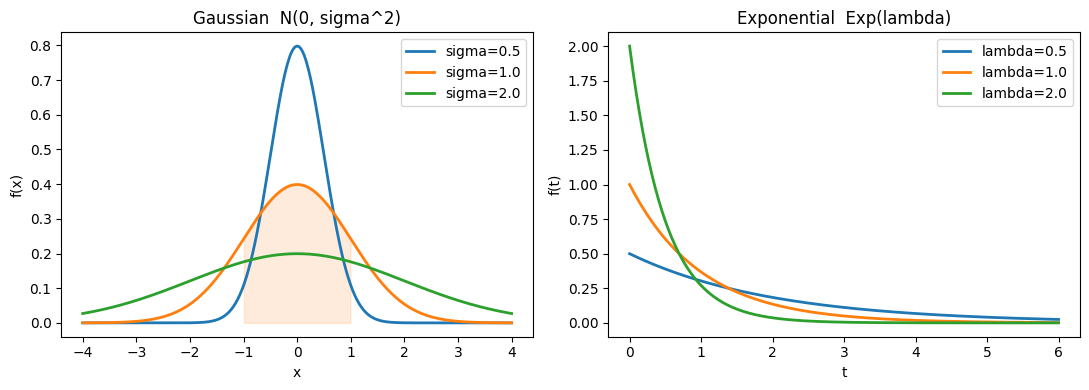

In [14]:
# Side-by-side: Gaussian vs Exponential
x_vals = np.linspace(-4, 4, 400)
t_vals = np.linspace(0, 6, 400)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Gaussian family
for sig, col in [(0.5,'#1f77b4'), (1.0,'#ff7f0e'), (2.0,'#2ca02c')]:
    y_g = np.exp(-x_vals**2/(2*sig**2)) / (sig*np.sqrt(2*np.pi))
    ax1.plot(x_vals, y_g, lw=2, color=col, label=f'sigma={sig}')
ax1.set_title('Gaussian  N(0, sigma^2)'); ax1.set_xlabel('x')
ax1.set_ylabel('f(x)'); ax1.legend()
ax1.fill_between(x_vals, np.exp(-x_vals**2/2)/np.sqrt(2*np.pi),
                 where=(np.abs(x_vals)<1), alpha=0.15, color='#ff7f0e',
                 label='68%')

# Exponential family
for lam_v, col in [(0.5,'#1f77b4'), (1.0,'#ff7f0e'), (2.0,'#2ca02c')]:
    y_e = lam_v * np.exp(-lam_v * t_vals)
    ax2.plot(t_vals, y_e, lw=2, color=col, label=f'lambda={lam_v}')
ax2.set_title('Exponential  Exp(lambda)'); ax2.set_xlabel('t')
ax2.set_ylabel('f(t)'); ax2.legend()

plt.tight_layout(); plt.savefig('distributions.png', dpi=100); plt.show()


---
## §5 — Expected Value, Variance, and Moment Generating Functions

The **moments** of a distribution encode its shape completely.

| Moment | Formula | Meaning |
|--------|---------|---------|
| $E[X]$ | $\int x\,f(x)\,dx$ | center of mass |
| $\text{Var}(X) = E[X^2] - E[X]^2$ | spread | |
| $\text{Skew} = E[(X-\mu)^3]/\sigma^3$ | asymmetry | |
| $\text{Kurt} = E[(X-\mu)^4]/\sigma^4 - 3$ | tail weight | |

**Moment Generating Function** (MGF): $M_X(t) = E[e^{tX}]$

$$E[X^n] = \left.\frac{d^n M_X}{dt^n}\right|_{t=0}$$


In [15]:
# MGF -> moments for Gaussian
t_sym = sp.Symbol('t')
sig_val, mu_val = sp.Symbol('sigma', positive=True), sp.Symbol('mu')
M_gaussian = sp.exp(mu_val*t_sym + sp.Rational(1,2)*sig_val**2*t_sym**2)

# First moment: dM/dt at t=0
E1 = sp.diff(M_gaussian, t_sym).subs(t_sym, 0)
E2 = sp.diff(M_gaussian, t_sym, 2).subs(t_sym, 0)
var_from_mgf = sp.simplify(E2 - E1**2)

print("MGF of Gaussian: M(t) = exp(mu*t + sigma^2*t^2/2)")
print(f"  E[X]   = dM/dt|_{{t=0}} = {E1}")
print(f"  E[X^2] = d^2M/dt^2|_{{t=0}} = {sp.expand(E2)}")
print(f"  Var(X) = E[X^2] - E[X]^2 = {var_from_mgf}")


MGF of Gaussian: M(t) = exp(mu*t + sigma^2*t^2/2)
  E[X]   = dM/dt|_{t=0} = mu
  E[X^2] = d^2M/dt^2|_{t=0} = mu**2 + sigma**2
  Var(X) = E[X^2] - E[X]^2 = sigma**2


In [16]:
# Variance shortcut and covariance
X, Y = sp.symbols('X Y')
# Key identities as SymPy Eq objects
Var_X = sp.Symbol('Var_X')
E_X, E_Y = sp.Symbol('E_X'), sp.Symbol('E_Y')

shortcut = sp.Eq(sp.Symbol('Var(X)'),
                 sp.Symbol('E[X^2]') - sp.Symbol('E[X]')**2)
cov_eq   = sp.Eq(sp.Symbol('Cov(X,Y)'),
                 sp.Symbol('E[XY]') - sp.Symbol('E[X]')*sp.Symbol('E[Y]'))
corr_eq  = sp.Eq(sp.Symbol('rho'),
                 sp.Symbol('Cov(X,Y)') /
                 (sp.sqrt(sp.Symbol('Var_X'))*sp.sqrt(sp.Symbol('Var_Y'))))

print("Variance shortcut:"); display(shortcut)
print("\nCovariance:"); display(cov_eq)
print("\nCorrelation coefficient:"); display(corr_eq)

# Cauchy-Schwarz: |Cov(X,Y)| <= sqrt(Var X * Var Y)
cs = sp.Le(sp.Abs(sp.Symbol('Cov(X,Y)')),
           sp.sqrt(sp.Symbol('Var_X') * sp.Symbol('Var_Y')))
print("\nCauchy-Schwarz inequality:")
display(cs)
print("=> -1 <= rho <= 1  always")


Variance shortcut:


               2          
Var(X) = - E[X]  + E[X__2]


Covariance:


Cov(X,Y) = E[XY] - E[X]⋅E[Y]


Correlation coefficient:


         Cov(X,Y)      
ρ = ───────────────────
      _______   _______
    ╲╱ Var_X ⋅╲╱ Var_Y 


Cauchy-Schwarz inequality:


               _____________
│Cov(X,Y)│ ≤ ╲╱ Var_X⋅Var_Y 

=> -1 <= rho <= 1  always


In [17]:
# Entropy H = -E[log p(X)] -- information theory meets statistics
H_continuous = sp.Eq(sp.Symbol('H[X]'),
    -sp.Integral(sp.Symbol('f(x)') * sp.log(sp.Symbol('f(x)')), (x, -sp.oo, sp.oo)))
H_discrete   = sp.Eq(sp.Symbol('H[X]'),
    -sp.Sum(sp.Symbol('p_i') * sp.log(sp.Symbol('p_i')), (i, 1, n)))

print("Differential entropy (continuous):"); display(H_continuous)
print("\nShannon entropy (discrete):"); display(H_discrete)

# Gaussian has maximum entropy for fixed variance
# H(Gaussian) = (1/2)*ln(2*pi*e*sigma^2)
H_gauss = sp.Rational(1,2) * sp.log(2*sp.pi*sp.E*sig_val**2)
H_gauss_eq = sp.Eq(sp.Symbol('H[N(mu,sigma^2)]'), H_gauss)
print("\nGaussian is maximum-entropy for fixed variance:")
display(H_gauss_eq)
print("  (This is why the CLT always converges to a Gaussian!)")


Differential entropy (continuous):


        ∞                   
        ⌠                   
H[X] = -⎮  f(x)⋅log(f(x)) dx
        ⌡                   
        -∞                  


Shannon entropy (discrete):


          n             
         ___            
         ╲              
          ╲             
H[X] = -  ╱   pᵢ⋅log(pᵢ)
         ╱              
         ‾‾‾            
        i = 1           


Gaussian is maximum-entropy for fixed variance:


                       ⎛       2⎞
                    log⎝2⋅ℯ⋅π⋅σ ⎠
H[N(mu,sigma__2)] = ─────────────
                          2      

  (This is why the CLT always converges to a Gaussian!)


---
## §6 — Central Limit Theorem

**The most important theorem in statistics:**

> Let $X_1, X_2, \ldots, X_n$ be i.i.d. with mean $\mu$ and variance $\sigma^2$.
> Define the sample mean $\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i$.
> Then as $n \to \infty$:
>
> $$\sqrt{n}\,\frac{\bar{X}_n - \mu}{\sigma} \;\xrightarrow{d}\; \mathcal{N}(0,1)$$

### Why physics creates this math

Boltzmann (1872) summed the kinetic energies of $N \sim 10^{23}$ gas molecules.
Each molecule has some weird, complicated velocity distribution.
But the **total energy** is Gaussian — because of the CLT.
Maxwell's velocity distribution follows from CLT applied to 3D components.

The **characteristic function** proof is the cleanest:

$$\varphi_{\bar{X}_n}(t) = \left[\varphi_X\!\left(\frac{t}{\sqrt{n}}\right)\right]^n \;\to\; e^{-t^2/2}$$


In [18]:
# CLT characteristic function proof
t_cf = sp.Symbol('t')
phi_X = sp.Function('phi_X')
n_sym2 = sp.Symbol('n', integer=True, positive=True)

# Taylor expand phi_X(t/sqrt(n)) around 0
# phi_X(s) ~ 1 + i*mu*s - (sigma^2+mu^2)/2 * s^2 + ...
# For standardized (mu=0, sigma=1): phi_X(t/sqrt(n)) ~ 1 - t^2/(2n) + O(1/n^2)
# -> [1 - t^2/(2n)]^n -> exp(-t^2/2) as n->inf

eps = sp.Symbol('epsilon')
phi_approx = 1 - t_cf**2 / (2*n_sym2)
limit_expr = sp.limit(phi_approx**n_sym2, n_sym2, sp.oo)

clt_eq = sp.Eq(
    sp.Symbol('phi_{Xbar_n}(t)'),
    sp.Symbol('[phi_X(t/sqrt(n))]^n')
)
print("CLT via characteristic functions:")
display(clt_eq)
print(f"\nlim_{{n->inf}} (1 - t^2/(2n))^n = {limit_expr}")
std_normal_cf = sp.Eq(sp.Symbol('phi_{Z}(t)'), sp.exp(-t_cf**2/2))
print("Standard normal characteristic function:")
display(std_normal_cf)


CLT via characteristic functions:


φ_{X̅_n}(t) = [phi_X(t/sqrt(n))]__n


lim_{n->inf} (1 - t^2/(2n))^n = exp(-t**2/2)
Standard normal characteristic function:


              2 
            -t  
            ────
             2  
φ_{Z}(t) = ℯ    

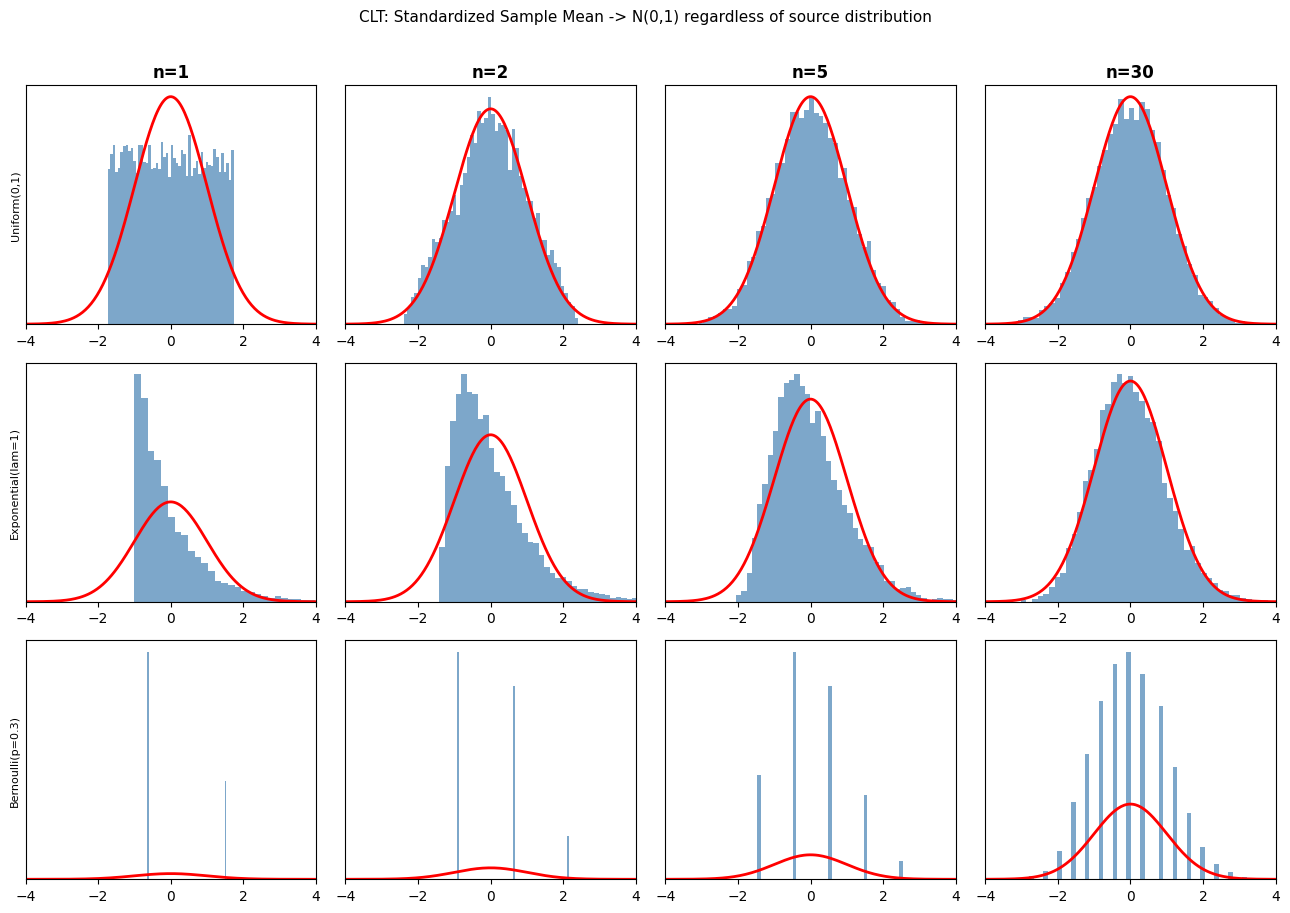

In [19]:
# CLT numerical demonstration: sum of Uniform, Exponential, Bernoulli
rng = np.random.default_rng(42)
N_trials = 8000
n_list   = [1, 2, 5, 30]

fig, axes = plt.subplots(3, 4, figsize=(13, 9))
dist_names = ['Uniform(0,1)', 'Exponential(lam=1)', 'Bernoulli(p=0.3)']

def draw_samples(dist, n, N):
    if dist == 0:
        raw = rng.uniform(0, 1, (N, n)); mu_d, sig_d = 0.5, 1/np.sqrt(12)
    elif dist == 1:
        raw = rng.exponential(1.0, (N, n)); mu_d, sig_d = 1.0, 1.0
    else:
        raw = rng.binomial(1, 0.3, (N, n)).astype(float); mu_d, sig_d = 0.3, np.sqrt(0.21)
    Z = (raw.mean(axis=1) - mu_d) / (sig_d / np.sqrt(n))
    return Z

z_range = np.linspace(-4, 4, 200)
std_norm_y = np.exp(-z_range**2 / 2) / np.sqrt(2*np.pi)

for row, dist in enumerate(range(3)):
    for col, n_v in enumerate(n_list):
        ax = axes[row][col]
        Z = draw_samples(dist, n_v, N_trials)
        ax.hist(Z, bins=50, density=True, color='steelblue', alpha=0.7)
        ax.plot(z_range, std_norm_y, 'r-', lw=2, label='N(0,1)')
        if col == 0: ax.set_ylabel(dist_names[dist], fontsize=8)
        if row == 0: ax.set_title(f'n={n_v}', fontweight='bold')
        ax.set_xlim(-4, 4); ax.set_yticks([])

plt.suptitle('CLT: Standardized Sample Mean -> N(0,1) regardless of source distribution',
             fontsize=11, y=1.01)
plt.tight_layout(); plt.savefig('clt_demo.png', dpi=100); plt.show()


### §6.2 Physics Creates New Math: A Scorecard

| Statistical Concept | Physics Problem That Invented It |
|---------------------|----------------------------------|
| Gaussian distribution | Maxwell (1860): molecular speeds |
| Poisson distribution | Einstein (1905): photon shot noise |
| Entropy $H = -\sum p\log p$ | Boltzmann (1872): $S = k_B \ln\Omega$ |
| Brownian motion / diffusion | Einstein (1905): pollen in water |
| Quantum probability $|\psi|^2$ | Born (1926): wavefunction interpretation |
| Large deviation theory | Cramér (1938): motivated by insurance; used in stat mech |
| Random matrix theory | Wigner (1951): nuclear energy levels |
| TS-DFT SNR = $\sqrt{N_\text{photons}}$ | Jalali (2009): Poisson shot noise in fiber |

The deepest truth: **entropy maximization under constraints gives every
major distribution** — Gaussian (fixed variance), Poisson (fixed mean),
exponential (fixed mean, $t\ge 0$). This is the *maximum entropy principle*,
due to Jaynes (1957), who was a physicist writing about thermodynamics.


In [20]:
# Maximum entropy principle: Lagrange multiplier derivation
# Maximize H = -int f*log(f) dx subject to:
#   int f dx = 1    (normalization)
#   int x^2 f dx = sigma^2   (fixed variance, zero mean)
# -> Euler-Lagrange -> f(x) = exp(-lambda_0 - lambda_2 * x^2)
# -> Gaussian!

f_sym  = sp.Function('f')
lam0, lam2 = sp.symbols('lambda_0 lambda_2', positive=True)

# The variational condition: d/df [-f*log(f) - lam0*f - lam2*x^2*f] = 0
integrand = -f_sym(x)*sp.log(f_sym(x)) - lam0*f_sym(x) - lam2*x**2*f_sym(x)
euler_lag  = sp.diff(integrand, f_sym(x))
print("Euler-Lagrange condition (dL/df = 0):")
display(sp.Eq(euler_lag, 0))

# Solve for f
sol = sp.solve(euler_lag, f_sym(x))[0]
print("\nMaximum-entropy f(x):")
display(sp.Eq(sp.Symbol('f*(x)'), sol))
print("=> f(x) = exp(-lam0 - lam2*x^2)  i.e., GAUSSIAN")
print("   Fixing lam0, lam2 via constraints gives N(0, 1/(2*lam2))")


Euler-Lagrange condition (dL/df = 0):


          2                    
-λ₀ - λ₂⋅x  - log(f(x)) - 1 = 0


Maximum-entropy f(x):


                   2    
         -λ₀ - λ₂⋅x  - 1
f*(x) = ℯ               

=> f(x) = exp(-lam0 - lam2*x^2)  i.e., GAUSSIAN
   Fixing lam0, lam2 via constraints gives N(0, 1/(2*lam2))


In [21]:
# Final summary: all 5 sympy equations from dgs/statistics.py
import sys, os
# notebooks/ is one level below repo root
_repo = os.path.abspath(os.path.join(os.getcwd(), '..'))
if _repo not in sys.path:
    sys.path.insert(0, _repo)
from dgs.statistics import statistics_sympy_5

print("SymPy equations from dgs/statistics.py:")
eqs = statistics_sympy_5()
for name, eq in eqs.items():
    print(f"\n{name}:")
    display(eq)


SymPy equations from dgs/statistics.py:

Gaussian_pdf:


                    2 
           -(-μ + x)  
           ───────────
                 2    
              2⋅σ     
       √2⋅ℯ           
f(x) = ───────────────
           2⋅√π⋅σ     


CLT_standard_error:


     σ 
SE = ──
     √n


Bayes_theorem:


         P(B|A)⋅P_A
P(A|B) = ──────────
            P_B    


Triangle_inequality:


||f+g|| = ||f+g||ᵥₐₗ ≤ ||f|| + ||g||


Attention_decay:


                     -λ⋅t
P(attending at t) = ℯ    

---
## Summary

| Section | Core result |
|---------|-------------|
| §1 Axioms | $P(\Omega)=1$; Bayes' theorem |
| §2 Combinatorics | $\binom{n}{k}$; Stirling's $\ln n! \approx n\ln n - n$ |
| §3 Discrete | Binomial → Poisson as $n\to\infty, p\to 0, np=\lambda$ |
| §4 Continuous | Gaussian (max entropy); Exponential (memoryless) |
| §5 Moments | MGF encodes all moments; $\text{Var} = E[X^2]-E[X]^2$ |
| §6 CLT | $\sqrt{n}(\bar X - \mu)/\sigma \to N(0,1)$ via characteristic functions |

**Physics → Math pipeline**: every classical distribution was first *needed*
by a physicist before it was *proved* by a mathematician.
The next generation: TS-DFT shot noise, quantum Fisher information,
and tensor network entropy are creating the statistics of 2040.
